# ⭐ Day 16: Pandas Merging, Joining & Concatenation
Combining Multiple Datasets for AI & ML | Step-by-Step Tutorial with Examples & Exercises

*Day 16 of 369-day Python & AI Learning Path*

## 💡 Introduction

Welcome to Day 16 of your Python & AI Learning Journey! Today we tackle one of the most practical and frequently used skills in data science: **combining multiple datasets**. In the real world, data rarely comes in a single, perfectly formatted file. Instead, it's scattered across multiple tables, files, and databases.

**Why is mastering data combination crucial for AI/ML?**

1. **Real-World Data Fragmentation**: Machine learning projects typically involve multiple data sources—customer demographics in one table, transaction history in another, product information in a third. Your ability to combine these efficiently determines your modeling success.

2. **Preventing Data Leakage**: Improper merging can cause information from the test set to leak into the training set, leading to overoptimistic performance estimates. Understanding merge mechanics helps you build robust validation pipelines.

3. **Feature Enrichment**: Often, the most powerful features come from auxiliary datasets—geographic data, external APIs, or lookup tables. Proper joining techniques allow you to enrich your primary dataset safely.

4. **Avoiding Bias and Errors**: Wrong join types can silently drop important records or create duplicate entries, introducing bias or errors that compromise model performance.

5. **Efficiency at Scale**: In production ML pipelines, inefficient merging can become a bottleneck. Knowing the right strategy for each situation saves computation time and memory.

By the end of this tutorial, you'll confidently combine datasets using concatenation, various merge strategies, and handle complex scenarios like duplicate keys and overlapping columns. Let's dive in!

## 📌 Table of Contents

1. [Setting Up & Creating Sample Datasets](#setup)
2. [Concatenation: pd.concat()](#concat)
3. [Merging Basics: pd.merge()](#merge-basics)
4. [Join Types: Inner, Left, Right, Outer](#join-types)
5. [Merging on Different Columns](#merge-columns)
6. [Handling Column Name Conflicts](#suffixes)
7. [Duplicate Keys and Many-to-Many Relationships](#duplicates)
8. [Joining on Index](#index-join)
9. [Real AI/ML Examples](#ml-examples)
10. [🛠️ Hands-On Exercises](#exercises)
11. [Solutions](#solutions)

## 1. Setting Up & Creating Sample Datasets {#setup}

Let's create realistic datasets that simulate a typical e-commerce scenario with customers, transactions, products, and categories.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

# Dataset 1: Customers (Primary table)
customers = pd.DataFrame({
    'customer_id': [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008],
    'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank', 'Grace', 'Henry'],
    'age': [25, 34, 45, 29, 52, 38, 41, 27],
    'city': ['New York', 'Los Angeles', 'Chicago', 'New York', 'Chicago', 'Los Angeles', 'New York', 'Chicago'],
    'signup_date': pd.to_datetime(['2023-01-15', '2023-02-20', '2023-03-10', '2023-01-25', 
                                   '2023-04-05', '2023-02-28', '2023-03-15', '2023-01-10'])
})

# Dataset 2: Transactions (Some customers may not have transactions yet)
transactions = pd.DataFrame({
    'transaction_id': ['T001', 'T002', 'T003', 'T004', 'T005', 'T006', 'T007', 'T008', 'T009', 'T010'],
    'customer_id': [1001, 1001, 1002, 1003, 1004, 1004, 1005, 1006, 1009, 1010],
    'product_id': ['P01', 'P03', 'P02', 'P01', 'P04', 'P02', 'P03', 'P01', 'P05', 'P02'],
    'amount': [120.50, 85.00, 250.00, 45.99, 180.00, 95.50, 320.00, 150.00, 75.00, 200.00],
    'transaction_date': pd.to_datetime(['2023-06-01', '2023-06-15', '2023-06-10', '2023-06-20',
                                         '2023-06-05', '2023-06-25', '2023-06-12', '2023-06-18',
                                         '2023-06-08', '2023-06-22'])
})

# Dataset 3: Product Information (Lookup table)
products = pd.DataFrame({
    'product_id': ['P01', 'P02', 'P03', 'P04', 'P05', 'P06'],
    'product_name': ['Wireless Mouse', 'Mechanical Keyboard', 'USB-C Hub', 'Webcam 4K', 'Laptop Stand', 'Monitor Arm'],
    'category': ['Electronics', 'Electronics', 'Electronics', 'Electronics', 'Accessories', 'Accessories'],
    'price': [49.99, 129.99, 79.99, 199.99, 45.00, 89.99],
    'supplier_id': ['S1', 'S2', 'S1', 'S3', 'S2', 'S3']
})

# Dataset 4: Suppliers (Auxiliary data)
suppliers = pd.DataFrame({
    'supplier_id': ['S1', 'S2', 'S3', 'S4'],
    'supplier_name': ['TechCorp', 'GadgetPro', 'ElectroMax', 'FutureTech'],
    'country': ['USA', 'China', 'USA', 'Germany'],
    'rating': [4.5, 4.2, 4.8, 4.0]
})

print("📊 Dataset Shapes:")
print(f"Customers: {customers.shape}")
print(f"Transactions: {transactions.shape}")
print(f"Products: {products.shape}")
print(f"Suppliers: {suppliers.shape}")

print("\n🔍 Sample Data:")
print("\nCustomers:")
print(customers.head())
print("\nTransactions:")
print(transactions.head())

📊 Dataset Shapes:
Customers: (8, 5)
Transactions: (10, 5)
Products: (6, 5)
Suppliers: (4, 4)

🔍 Sample Data:

Customers:
   customer_id     name  age         city signup_date
0         1001    Alice   25     New York  2023-01-15
1         1002      Bob   34  Los Angeles  2023-02-20
2         1003  Charlie   45      Chicago  2023-03-10
3         1004    Diana   29     New York  2023-01-25
4         1005      Eve   52      Chicago  2023-04-05

Transactions:
  transaction_id  customer_id product_id  amount transaction_date
0           T001         1001        P01  120.50       2023-06-01
1           T002         1001        P03   85.00       2023-06-15
2           T003         1002        P02  250.00       2023-06-10
3           T004         1003        P01   45.99       2023-06-20
4           T005         1004        P04  180.00       2023-06-05


### Visualizing Dataset Relationships

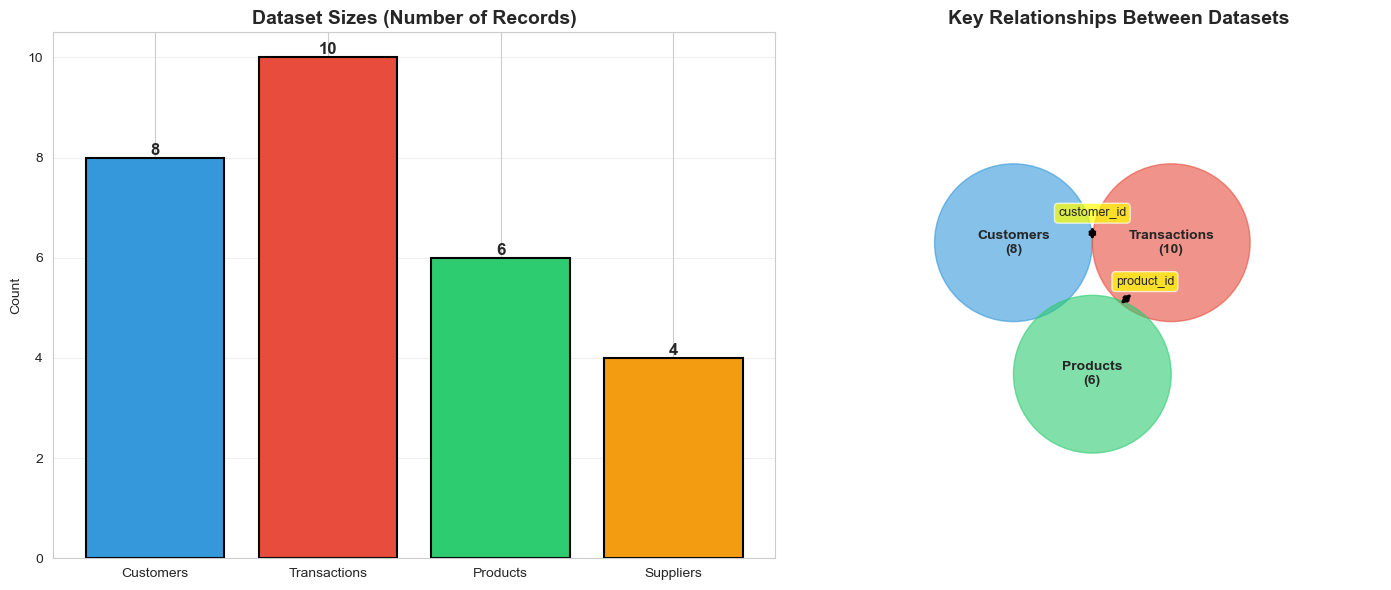


🔗 Key Join Keys:
- Customers & Transactions: customer_id
- Transactions & Products: product_id
- Products & Suppliers: supplier_id


In [2]:
# Create a visualization showing dataset sizes and key relationships
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot of dataset sizes
datasets = ['Customers', 'Transactions', 'Products', 'Suppliers']
sizes = [len(customers), len(transactions), len(products), len(suppliers)]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

bars = axes[0].bar(datasets, sizes, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('Dataset Sizes (Number of Records)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Venn-style diagram showing key overlaps (simplified representation)
axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 10)
axes[1].set_aspect('equal')
axes[1].axis('off')
axes[1].set_title('Key Relationships Between Datasets', fontsize=14, fontweight='bold')

# Draw circles representing datasets
circle1 = plt.Circle((3, 6), 1.5, color='#3498db', alpha=0.6, label='Customers')
circle2 = plt.Circle((6, 6), 1.5, color='#e74c3c', alpha=0.6, label='Transactions')
circle3 = plt.Circle((4.5, 3.5), 1.5, color='#2ecc71', alpha=0.6, label='Products')

axes[1].add_patch(circle1)
axes[1].add_patch(circle2)
axes[1].add_patch(circle3)

# Add labels
axes[1].text(3, 6, 'Customers\n(8)', ha='center', va='center', fontsize=10, fontweight='bold')
axes[1].text(6, 6, 'Transactions\n(10)', ha='center', va='center', fontsize=10, fontweight='bold')
axes[1].text(4.5, 3.5, 'Products\n(6)', ha='center', va='center', fontsize=10, fontweight='bold')

# Add relationship arrows/annotations
axes[1].annotate('customer_id', xy=(4.5, 6), xytext=(4.5, 6.5),
                arrowprops=dict(arrowstyle='<->', color='black', lw=2),
                fontsize=9, ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
axes[1].annotate('product_id', xy=(5, 4.8), xytext=(5.5, 5.2),
                arrowprops=dict(arrowstyle='<->', color='black', lw=2),
                fontsize=9, ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n🔗 Key Join Keys:")
print("- Customers & Transactions: customer_id")
print("- Transactions & Products: product_id")
print("- Products & Suppliers: supplier_id")

## 2. Concatenation: pd.concat() {#concat}

Concatenation is the simplest way to combine datasets—stacking them either vertically (adding rows) or horizontally (adding columns).

In [3]:
# Example 1: Concatenating along rows (axis=0)
# Split customers into two groups and recombine
customers_group1 = customers.iloc[:4]
customers_group2 = customers.iloc[4:]

print("Group 1 shape:", customers_group1.shape)
print("Group 2 shape:", customers_group2.shape)

# Concatenate vertically
customers_combined = pd.concat([customers_group1, customers_group2], axis=0)
print("\nCombined shape:", customers_combined.shape)
print("Original shape:", customers.shape)
print("Match:", customers_combined.shape == customers.shape)

# Example 2: Concatenating with ignore_index=True (reset index)
df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})
print("\nWith original indices:")
print(pd.concat([df1, df2]))
print("\nWith reset indices:")
print(pd.concat([df1, df2], ignore_index=True))

Group 1 shape: (4, 5)
Group 2 shape: (4, 5)

Combined shape: (8, 5)
Original shape: (8, 5)
Match: True

With original indices:
   A  B
0  1  3
1  2  4
0  5  7
1  6  8

With reset indices:
   A  B
0  1  3
1  2  4
2  5  7
3  6  8


In [4]:
# Example 3: Concatenating along columns (axis=1)
# Add new features to customers horizontally
customer_demographics = pd.DataFrame({
    'income_bracket': ['Low', 'Medium', 'High', 'Medium', 'High', 'Low', 'Medium', 'High'],
    'customer_segment': ['Budget', 'Standard', 'Premium', 'Standard', 'Premium', 'Budget', 'Standard', 'Premium']
}, index=customers.index)  # Important: same index!

customers_enhanced = pd.concat([customers, customer_demographics], axis=1)
print("Original customers shape:", customers.shape)
print("Enhanced customers shape:", customers_enhanced.shape)
print("\nEnhanced dataset:")
print(customers_enhanced.head())

# Example 4: Concatenating with keys (creating hierarchical index)
sales_q1 = pd.DataFrame({'sales': [100, 200, 300]})
sales_q2 = pd.DataFrame({'sales': [150, 250, 350]})
sales_multi = pd.concat([sales_q1, sales_q2], keys=['Q1', 'Q2'])
print("\nMulti-index concatenation:")
print(sales_multi)
print("\nAccessing Q1 data only:")
print(sales_multi.loc['Q1'])

Original customers shape: (8, 5)
Enhanced customers shape: (8, 7)

Enhanced dataset:
   customer_id     name  age         city signup_date income_bracket  \
0         1001    Alice   25     New York  2023-01-15            Low   
1         1002      Bob   34  Los Angeles  2023-02-20         Medium   
2         1003  Charlie   45      Chicago  2023-03-10           High   
3         1004    Diana   29     New York  2023-01-25         Medium   
4         1005      Eve   52      Chicago  2023-04-05           High   

  customer_segment  
0           Budget  
1         Standard  
2          Premium  
3         Standard  
4          Premium  

Multi-index concatenation:
      sales
Q1 0    100
   1    200
   2    300
Q2 0    150
   1    250
   2    350

Accessing Q1 data only:
   sales
0    100
1    200
2    300


## 3. Merging Basics: pd.merge() {#merge-basics}

Merging combines datasets based on common keys, similar to SQL joins. This is the most common operation when building ML datasets from multiple tables.

In [5]:
# Basic merge: Customers with their transactions
print("Before merge:")
print(f"Customers: {customers.shape}")
print(f"Transactions: {transactions.shape}")

# Inner merge (only customers with transactions)
customer_transactions = pd.merge(customers, transactions, on='customer_id', how='inner')
print(f"\nAfter inner merge: {customer_transactions.shape}")
print("\nFirst 5 rows:")
print(customer_transactions.head())

# Check which customers have transactions
print(f"\nUnique customers in transactions: {sorted(transactions['customer_id'].unique())}")
print(f"Customers in original data: {sorted(customers['customer_id'].unique())}")
print(f"Customers lost in inner merge: {set(customers['customer_id']) - set(transactions['customer_id'])}")

Before merge:
Customers: (8, 5)
Transactions: (10, 5)

After inner merge: (8, 9)

First 5 rows:
   customer_id     name  age         city signup_date transaction_id  \
0         1001    Alice   25     New York  2023-01-15           T001   
1         1001    Alice   25     New York  2023-01-15           T002   
2         1002      Bob   34  Los Angeles  2023-02-20           T003   
3         1003  Charlie   45      Chicago  2023-03-10           T004   
4         1004    Diana   29     New York  2023-01-25           T005   

  product_id  amount transaction_date  
0        P01  120.50       2023-06-01  
1        P03   85.00       2023-06-15  
2        P02  250.00       2023-06-10  
3        P01   45.99       2023-06-20  
4        P04  180.00       2023-06-05  

Unique customers in transactions: [np.int64(1001), np.int64(1002), np.int64(1003), np.int64(1004), np.int64(1005), np.int64(1006), np.int64(1009), np.int64(1010)]
Customers in original data: [np.int64(1001), np.int64(1002), np.int

## 4. Join Types: Inner, Left, Right, Outer {#join-types}

Choosing the right join type is critical for maintaining data integrity in ML pipelines.

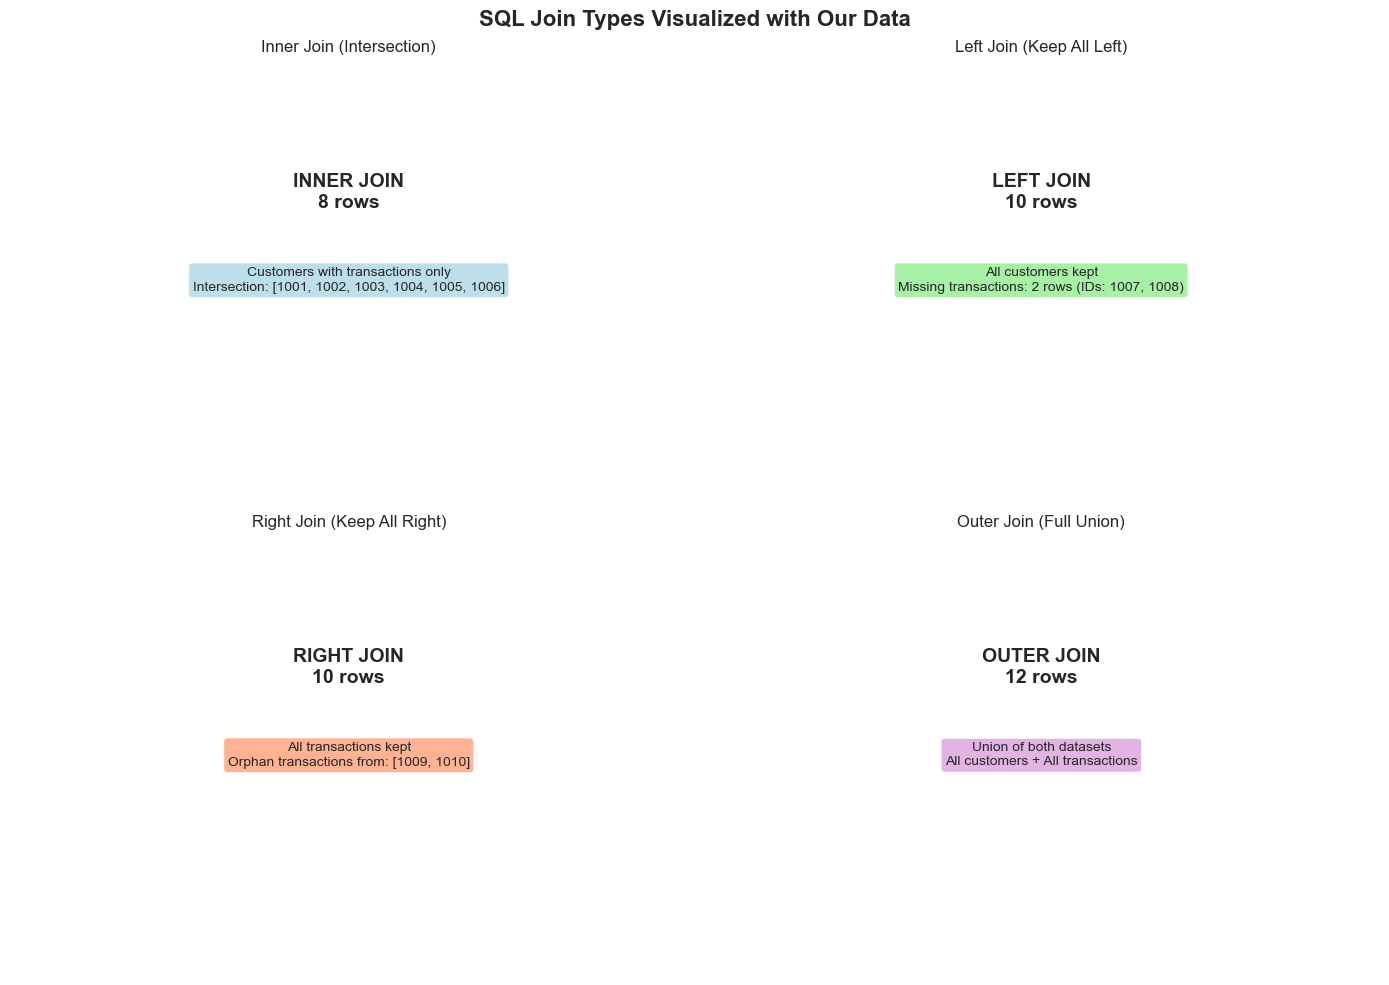

Summary of Join Results:
Inner: (8, 9) - Only matching customer_ids
Left:  (10, 9) - All customers, NaN for missing transactions
Right: (10, 9) - All transactions, NaN for missing customer info
Outer: (12, 9) - Everything from both tables


In [6]:
# Visualizing different join types
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SQL Join Types Visualized with Our Data', fontsize=16, fontweight='bold')

# Prepare data for visualization
customer_ids_orig = set(customers['customer_id'])
transaction_ids = set(transactions['customer_id'])

# Inner Join
inner_result = pd.merge(customers, transactions, on='customer_id', how='inner')
axes[0,0].text(0.5, 0.7, f'INNER JOIN\n{inner_result.shape[0]} rows', ha='center', va='center', 
               fontsize=14, fontweight='bold', transform=axes[0,0].transAxes)
axes[0,0].text(0.5, 0.5, f'Customers with transactions only\nIntersection: {sorted(customer_ids_orig & transaction_ids)}', 
               ha='center', va='center', fontsize=10, transform=axes[0,0].transAxes,
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[0,0].set_title('Inner Join (Intersection)', fontsize=12)
axes[0,0].axis('off')

# Left Join
left_result = pd.merge(customers, transactions, on='customer_id', how='left')
missing_in_left = left_result['transaction_id'].isna().sum()
axes[0,1].text(0.5, 0.7, f'LEFT JOIN\n{left_result.shape[0]} rows', ha='center', va='center',
               fontsize=14, fontweight='bold', transform=axes[0,1].transAxes)
axes[0,1].text(0.5, 0.5, f'All customers kept\nMissing transactions: {missing_in_left} rows (IDs: 1007, 1008)', 
               ha='center', va='center', fontsize=10, transform=axes[0,1].transAxes,
               bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
axes[0,1].set_title('Left Join (Keep All Left)', fontsize=12)
axes[0,1].axis('off')

# Right Join
right_result = pd.merge(customers, transactions, on='customer_id', how='right')
extra_in_right = set(transactions['customer_id']) - set(customers['customer_id'])
axes[1,0].text(0.5, 0.7, f'RIGHT JOIN\n{right_result.shape[0]} rows', ha='center', va='center',
               fontsize=14, fontweight='bold', transform=axes[1,0].transAxes)
axes[1,0].text(0.5, 0.5, f'All transactions kept\nOrphan transactions from: {sorted(extra_in_right)}', 
               ha='center', va='center', fontsize=10, transform=axes[1,0].transAxes,
               bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.8))
axes[1,0].set_title('Right Join (Keep All Right)', fontsize=12)
axes[1,0].axis('off')

# Outer Join
outer_result = pd.merge(customers, transactions, on='customer_id', how='outer')
axes[1,1].text(0.5, 0.7, f'OUTER JOIN\n{outer_result.shape[0]} rows', ha='center', va='center',
               fontsize=14, fontweight='bold', transform=axes[1,1].transAxes)
axes[1,1].text(0.5, 0.5, f'Union of both datasets\nAll customers + All transactions', 
               ha='center', va='center', fontsize=10, transform=axes[1,1].transAxes,
               bbox=dict(boxstyle='round', facecolor='plum', alpha=0.8))
axes[1,1].set_title('Outer Join (Full Union)', fontsize=12)
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

print("Summary of Join Results:")
print(f"Inner: {inner_result.shape} - Only matching customer_ids")
print(f"Left:  {left_result.shape} - All customers, NaN for missing transactions")
print(f"Right: {right_result.shape} - All transactions, NaN for missing customer info")
print(f"Outer: {outer_result.shape} - Everything from both tables")

In [7]:
# Practical demonstration of each join type
print("="*60)
print("INNER JOIN - Use when you only want complete cases")
print("="*60)
inner = pd.merge(customers, transactions, on='customer_id', how='inner')
print(f"Result: {inner.shape}")
print(inner[['customer_id', 'name', 'transaction_id', 'amount']].head())

print("\n" + "="*60)
print("LEFT JOIN - Use when preserving primary table is crucial")
print("="*60)
left = pd.merge(customers, transactions, on='customer_id', how='left')
print(f"Result: {left.shape}")
print("Customers without transactions show NaN:")
print(left[left['transaction_id'].isna()][['customer_id', 'name', 'transaction_id', 'amount']])

print("\n" + "="*60)
print("OUTER JOIN - Use when you cannot afford to lose any data")
print("="*60)
outer = pd.merge(customers, transactions, on='customer_id', how='outer')
print(f"Result: {outer.shape}")
print("All records preserved:")
print(outer[['customer_id', 'name', 'transaction_id', 'amount']].tail(3))

INNER JOIN - Use when you only want complete cases
Result: (8, 9)
   customer_id     name transaction_id  amount
0         1001    Alice           T001  120.50
1         1001    Alice           T002   85.00
2         1002      Bob           T003  250.00
3         1003  Charlie           T004   45.99
4         1004    Diana           T005  180.00

LEFT JOIN - Use when preserving primary table is crucial
Result: (10, 9)
Customers without transactions show NaN:
   customer_id   name transaction_id  amount
8         1007  Grace            NaN     NaN
9         1008  Henry            NaN     NaN

OUTER JOIN - Use when you cannot afford to lose any data
Result: (12, 9)
All records preserved:
    customer_id   name transaction_id  amount
9          1008  Henry            NaN     NaN
10         1009    NaN           T009    75.0
11         1010    NaN           T010   200.0


## 5. Merging on Different Columns {#merge-columns}

Often, the key columns have different names in different tables.

In [8]:
# Merging when key columns have different names
# Create a modified transactions table with 'cust_id' instead of 'customer_id'
transactions_alt = transactions.rename(columns={'customer_id': 'cust_id'})

print("Transactions column names:", transactions_alt.columns.tolist())
print("Customers column names:", customers.columns.tolist())

# Merge with different column names
merged_diff_cols = pd.merge(
    customers, 
    transactions_alt, 
    left_on='customer_id', 
    right_on='cust_id',
    how='inner'
)
print(f"\nMerged shape: {merged_diff_cols.shape}")
print("Note: Both keys are preserved in the result:")
print(merged_diff_cols[['customer_id', 'cust_id', 'name']].head())

# Clean up by dropping duplicate key
merged_clean = merged_diff_cols.drop('cust_id', axis=1)
print(f"\nAfter dropping duplicate key: {merged_clean.shape}")
print(merged_clean.head())

Transactions column names: ['transaction_id', 'cust_id', 'product_id', 'amount', 'transaction_date']
Customers column names: ['customer_id', 'name', 'age', 'city', 'signup_date']

Merged shape: (8, 10)
Note: Both keys are preserved in the result:
   customer_id  cust_id     name
0         1001     1001    Alice
1         1001     1001    Alice
2         1002     1002      Bob
3         1003     1003  Charlie
4         1004     1004    Diana

After dropping duplicate key: (8, 9)
   customer_id     name  age         city signup_date transaction_id  \
0         1001    Alice   25     New York  2023-01-15           T001   
1         1001    Alice   25     New York  2023-01-15           T002   
2         1002      Bob   34  Los Angeles  2023-02-20           T003   
3         1003  Charlie   45      Chicago  2023-03-10           T004   
4         1004    Diana   29     New York  2023-01-25           T005   

  product_id  amount transaction_date  
0        P01  120.50       2023-06-01  
1   

## 6. Handling Column Name Conflicts {#suffixes}

When both tables have columns with the same name (other than the key), Pandas adds suffixes.

In [9]:
# Create tables with overlapping column names
orders = pd.DataFrame({
    'order_id': ['O1', 'O2', 'O3'],
    'customer_id': [1001, 1002, 1003],
    'date': ['2023-01-01', '2023-01-02', '2023-01-03'],
    'amount': [100, 200, 300]
})

shipments = pd.DataFrame({
    'shipment_id': ['S1', 'S2', 'S3'],
    'order_id': ['O1', 'O2', 'O4'],
    'date': ['2023-01-02', '2023-01-03', '2023-01-04'],
    'status': ['Delivered', 'In Transit', 'Pending']
})

print("Orders columns:", orders.columns.tolist())
print("Shipments columns:", shipments.columns.tolist())
print("\nBoth have 'date' column!")

# Default suffixes
default_merge = pd.merge(orders, shipments, on='order_id', how='inner')
print("\nDefault suffixes (_x, _y):")
print(default_merge)

# Custom suffixes
custom_merge = pd.merge(orders, shipments, on='order_id', how='inner', 
                       suffixes=('_order', '_shipment'))
print("\nCustom suffixes:")
print(custom_merge[['order_id', 'date_order', 'date_shipment', 'amount', 'status']])

Orders columns: ['order_id', 'customer_id', 'date', 'amount']
Shipments columns: ['shipment_id', 'order_id', 'date', 'status']

Both have 'date' column!

Default suffixes (_x, _y):
  order_id  customer_id      date_x  amount shipment_id      date_y  \
0       O1         1001  2023-01-01     100          S1  2023-01-02   
1       O2         1002  2023-01-02     200          S2  2023-01-03   

       status  
0   Delivered  
1  In Transit  

Custom suffixes:
  order_id  date_order date_shipment  amount      status
0       O1  2023-01-01    2023-01-02     100   Delivered
1       O2  2023-01-02    2023-01-03     200  In Transit


## 7. Duplicate Keys and Many-to-Many Relationships {#duplicates}

Understanding how Pandas handles duplicate keys is essential for preventing data explosion in merges.

In [10]:
# One-to-Many relationship (Customer -> Multiple Transactions)
print("One-to-Many: Customer to Transactions")
print(f"Unique customers: {customers['customer_id'].nunique()}")
print(f"Total transactions: {len(transactions)}")

one_to_many = pd.merge(customers, transactions, on='customer_id', how='inner')
print(f"After merge: {one_to_many.shape[0]} rows (duplicates expected for customers with multiple transactions)")
print("\nCustomer 1001 appears twice (2 transactions):")
print(one_to_many[one_to_many['customer_id'] == 1001][['customer_id', 'name', 'transaction_id', 'amount']])

# Many-to-Many scenario simulation
# Create a customer_tags table (a customer can have multiple tags)
customer_tags = pd.DataFrame({
    'customer_id': [1001, 1001, 1002, 1002, 1003, 1004],
    'tag': ['Premium', 'Tech', 'Budget', 'Tech', 'Premium', 'New']
})

print("\n" + "="*50)
print("Many-to-Many: Customers with multiple tags + Transactions")
print("="*50)
print(f"Customer tags: {len(customer_tags)} rows")
print(customer_tags.head())

# First merge: customers with tags
customers_with_tags = pd.merge(customers, customer_tags, on='customer_id', how='left')
print(f"\nAfter adding tags: {customers_with_tags.shape[0]} rows (Customer 1001 now appears twice)")
print(customers_with_tags[customers_with_tags['customer_id'] == 1001][['customer_id', 'name', 'tag']])

# Many-to-Many merge warning
print("\n⚠️  Warning: Merging this with transactions creates a Cartesian product!")
many_to_many = pd.merge(customers_with_tags, transactions, on='customer_id', how='inner')
print(f"Result: {many_to_many.shape[0]} rows")
print("Customer 1001 (2 tags × 2 transactions = 4 rows):")
print(many_to_many[many_to_many['customer_id'] == 1001][['customer_id', 'name', 'tag', 'transaction_id', 'amount']])

One-to-Many: Customer to Transactions
Unique customers: 8
Total transactions: 10
After merge: 8 rows (duplicates expected for customers with multiple transactions)

Customer 1001 appears twice (2 transactions):
   customer_id   name transaction_id  amount
0         1001  Alice           T001   120.5
1         1001  Alice           T002    85.0

Many-to-Many: Customers with multiple tags + Transactions
Customer tags: 6 rows
   customer_id      tag
0         1001  Premium
1         1001     Tech
2         1002   Budget
3         1002     Tech
4         1003  Premium

After adding tags: 10 rows (Customer 1001 now appears twice)
   customer_id   name      tag
0         1001  Alice  Premium
1         1001  Alice     Tech

⚠️  Warning: Merging this with transactions creates a Cartesian product!
Result: 11 rows
Customer 1001 (2 tags × 2 transactions = 4 rows):
   customer_id   name      tag transaction_id  amount
0         1001  Alice  Premium           T001   120.5
1         1001  Alice  Pre

## 8. Joining on Index {#index-join}

Sometimes it's more efficient to join on the DataFrame index rather than a column.

In [11]:
# Set index for joining
customers_indexed = customers.set_index('customer_id')
transactions_indexed = transactions.set_index('customer_id')

print("Customers indexed:")
print(customers_indexed.head())

# Join on index
index_join = customers_indexed.join(transactions_indexed, how='inner')
print(f"\nJoin on index result: {index_join.shape}")
print(index_join.head())

# Using merge with index options
# Reset index to demonstrate merge with left_index and right_index
result_index_merge = pd.merge(
    customers_indexed, 
    transactions_indexed, 
    left_index=True, 
    right_index=True,
    how='inner'
)
print(f"\nMerge with index options: {result_index_merge.shape}")
print(result_index_merge.head())

Customers indexed:
                name  age         city signup_date
customer_id                                       
1001           Alice   25     New York  2023-01-15
1002             Bob   34  Los Angeles  2023-02-20
1003         Charlie   45      Chicago  2023-03-10
1004           Diana   29     New York  2023-01-25
1005             Eve   52      Chicago  2023-04-05

Join on index result: (8, 8)
                name  age         city signup_date transaction_id product_id  \
customer_id                                                                    
1001           Alice   25     New York  2023-01-15           T001        P01   
1001           Alice   25     New York  2023-01-15           T002        P03   
1002             Bob   34  Los Angeles  2023-02-20           T003        P02   
1003         Charlie   45      Chicago  2023-03-10           T004        P01   
1004           Diana   29     New York  2023-01-25           T005        P04   

             amount transaction_d

## 9. Real AI/ML Examples {#ml-examples}

Let's put it all together with practical ML scenarios.

In [12]:
# ML Example 1: Building a complete feature matrix
print("="*60)
print("ML PIPELINE: Building Complete Feature Dataset")
print("="*60)

# Step 1: Start with transactions (our primary events)
print("\nStep 1: Base transactions data")
ml_data = transactions.copy()
print(f"Shape: {ml_data.shape}")

# Step 2: Add customer features (LEFT JOIN to keep all transactions)
print("\nStep 2: Merge customer demographics (LEFT JOIN)")
ml_data = pd.merge(ml_data, customers, on='customer_id', how='left')
print(f"Shape: {ml_data.shape}")

# Step 3: Add product information (INNER JOIN - only if product exists)
print("\nStep 3: Merge product features (INNER JOIN)")
ml_data = pd.merge(ml_data, products, on='product_id', how='inner')
print(f"Shape: {ml_data.shape}")

# Step 4: Add supplier information (LEFT JOIN - supplier might be unknown)
print("\nStep 4: Merge supplier data (LEFT JOIN)")
ml_data = pd.merge(ml_data, suppliers, on='supplier_id', how='left')
print(f"Shape: {ml_data.shape}")

print("\nFinal dataset for ML:")
print(ml_data.head())
print(f"\nColumns: {ml_data.columns.tolist()}")

ML PIPELINE: Building Complete Feature Dataset

Step 1: Base transactions data
Shape: (10, 5)

Step 2: Merge customer demographics (LEFT JOIN)
Shape: (10, 9)

Step 3: Merge product features (INNER JOIN)
Shape: (10, 13)

Step 4: Merge supplier data (LEFT JOIN)
Shape: (10, 16)

Final dataset for ML:
  transaction_id  customer_id product_id  amount transaction_date     name  \
0           T001         1001        P01  120.50       2023-06-01    Alice   
1           T002         1001        P03   85.00       2023-06-15    Alice   
2           T003         1002        P02  250.00       2023-06-10      Bob   
3           T004         1003        P01   45.99       2023-06-20  Charlie   
4           T005         1004        P04  180.00       2023-06-05    Diana   

    age         city signup_date         product_name     category   price  \
0  25.0     New York  2023-01-15       Wireless Mouse  Electronics   49.99   
1  25.0     New York  2023-01-15            USB-C Hub  Electronics   79.99  

In [13]:
# ML Example 2: Proper train/test combination without leakage
print("\n" + "="*60)
print("ML BEST PRACTICE: Combining Train and Test Sets")
print("="*60)

# Simulate train and test sets
train_data = customers.iloc[:6].copy()
test_data = customers.iloc[6:].copy()
train_data['set'] = 'train'
test_data['set'] = 'test'

print(f"Train set: {train_data.shape}")
print(f"Test set: {test_data.shape}")

# CORRECT: Concatenate first, then process together (ensures same feature engineering)
combined = pd.concat([train_data, test_data], ignore_index=True)
print(f"\nCombined for preprocessing: {combined.shape}")

# Add a feature engineering step (e.g., age group)
combined['age_group'] = pd.cut(combined['age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle', 'Senior'])
print("\nAge groups created consistently across both sets:")
print(combined.groupby('set')['age_group'].value_counts())

# Later split back (in practice, use your original indices or a column to track)
train_final = combined[combined['set'] == 'train'].drop('set', axis=1)
test_final = combined[combined['set'] == 'test'].drop('set', axis=1)
print(f"\nSplit back - Train: {train_final.shape}, Test: {test_final.shape}")


ML BEST PRACTICE: Combining Train and Test Sets
Train set: (6, 6)
Test set: (2, 6)

Combined for preprocessing: (8, 6)

Age groups created consistently across both sets:
set    age_group
test   Young        1
       Middle       1
       Senior       0
train  Middle       3
       Young        2
       Senior       1
Name: count, dtype: int64

Split back - Train: (6, 6), Test: (2, 6)



DATA QUALITY: Analyzing Missing Values After Merge
Missing value analysis:
                            column  missing_count  missing_percent
product_id              product_id              2             20.0
amount                      amount              2             20.0
transaction_id      transaction_id              2             20.0
supplier_id            supplier_id              2             20.0
price                        price              2             20.0
category                  category              2             20.0
product_name          product_name              2             20.0
transaction_date  transaction_date              2             20.0
country                    country              2             20.0
supplier_name        supplier_name              2             20.0
rating                      rating              2             20.0


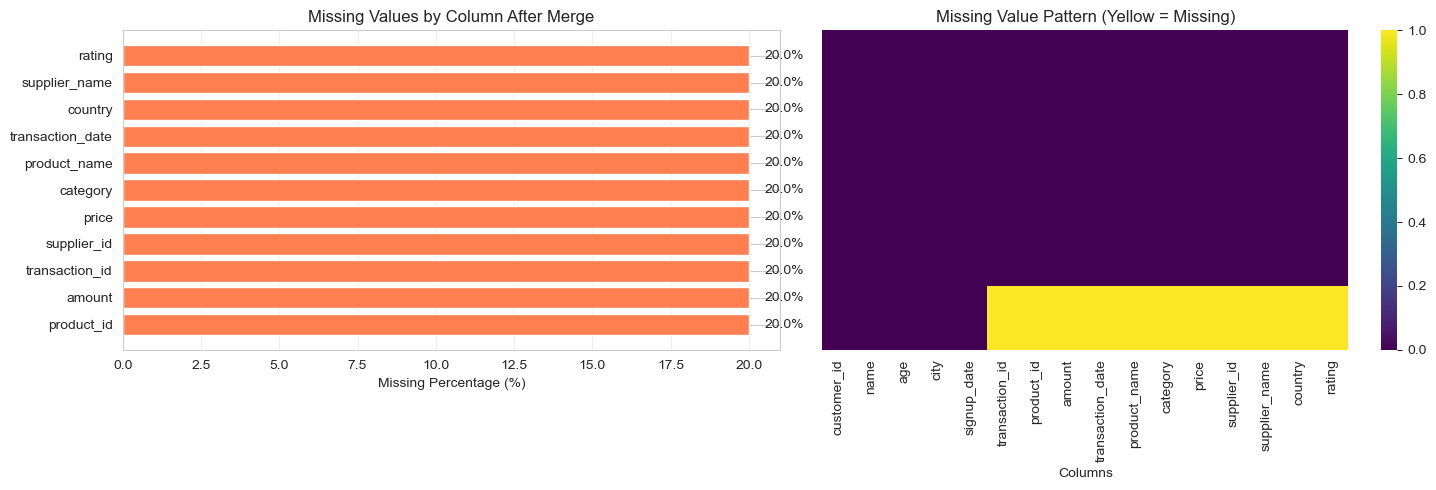


Total rows: 10
Complete cases (no missing): 8
Rows with any missing: 2


In [14]:
# ML Example 3: Handling missing data after merge
print("\n" + "="*60)
print("DATA QUALITY: Analyzing Missing Values After Merge")
print("="*60)

# Create a merge with missing values
full_data = pd.merge(customers, transactions, on='customer_id', how='left')
full_data = pd.merge(full_data, products, on='product_id', how='left')
full_data = pd.merge(full_data, suppliers, on='supplier_id', how='left')

# Calculate missing value percentages
missing_pct = (full_data.isnull().sum() / len(full_data) * 100).round(2)
missing_df = pd.DataFrame({
    'column': missing_pct.index,
    'missing_count': full_data.isnull().sum(),
    'missing_percent': missing_pct.values
}).sort_values('missing_percent', ascending=False)

print("Missing value analysis:")
print(missing_df[missing_df['missing_count'] > 0])

# Visualize missing value patterns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot of missing percentages
missing_cols = missing_df[missing_df['missing_count'] > 0]
if not missing_cols.empty:
    bars = axes[0].barh(missing_cols['column'], missing_cols['missing_percent'], color='coral')
    axes[0].set_xlabel('Missing Percentage (%)')
    axes[0].set_title('Missing Values by Column After Merge')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Add percentage labels
    for i, (bar, pct) in enumerate(zip(bars, missing_cols['missing_percent'])):
        axes[0].text(pct + 0.5, bar.get_y() + bar.get_height()/2, 
                    f'{pct}%', va='center', fontsize=10)

# Missing value heatmap
sns.heatmap(full_data.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Value Pattern (Yellow = Missing)')
axes[1].set_xlabel('Columns')

plt.tight_layout()
plt.show()

print(f"\nTotal rows: {len(full_data)}")
print(f"Complete cases (no missing): {full_data.dropna().shape[0]}")
print(f"Rows with any missing: {full_data.isnull().any(axis=1).sum()}")

## 🛠️ Hands-On Exercises

Complete these exercises to master data combination techniques!

### Exercise 1: Simple Concatenation
Concatenate the following two DataFrames vertically (along rows) and reset the index. Verify the final shape is correct.

```python
df_a = pd.DataFrame({'x': [1, 2], 'y': [3, 4]})
df_b = pd.DataFrame({'x': [5, 6], 'y': [7, 8]})
```

In [15]:
# your code here


### Exercise 2: Inner Merge
Perform an inner merge between `customers` and `transactions` on `customer_id`. How many rows result? Which customers are included?

In [16]:
# your code here


### Exercise 3: Left Merge
Perform a left merge between `customers` and `transactions` on `customer_id`. Count how many customers have no transactions (check for NaN in transaction_id).

In [17]:
# your code here


### Exercise 4: Right Merge
Perform a right merge between `customers` and `transactions` on `customer_id`. Identify any transactions that don't have matching customer information.

In [18]:
# your code here


### Exercise 5: Outer Merge
Perform an outer merge between `customers` and `transactions` on `customer_id`. Verify that all customer_ids from both tables are present in the result.

In [19]:
# your code here


### Exercise 6: Merging on Multiple Keys
Create a small DataFrame with columns `customer_id` and `city` representing customer preferences by city. Merge this with `customers` on both `customer_id` and `city` to find matching records.

In [20]:
# your code here


### Exercise 7: Handling Column Name Conflicts
Create two DataFrames that both have a column named `date`. Merge them and use custom suffixes `_order` and `_delivery` to distinguish the dates.

In [21]:
# your code here


### Exercise 8: Combining Features with Target Labels
Assume `transactions` is your feature set and you have a separate DataFrame `targets` with `customer_id` and `churned` (True/False). Perform a left merge to attach targets to transactions, ensuring all transactions are kept.

In [22]:
# your code here


### Exercise 9: Multi-Table Join for ML Dataset
Create a complete ML-ready dataset by:
1. Starting with `transactions`
2. Left joining `customers` on `customer_id`
3. Inner joining `products` on `product_id`
4. Left joining `suppliers` on `supplier_id`

Report the shape after each step and the final column count.

In [23]:
# your code here


### Exercise 10: Resolving Duplicate Issues
Given that customer 1001 has 2 transactions, calculate the average transaction amount per customer using a groupby BEFORE merging with customers, then merge the aggregated data. Compare the row count with a direct merge.

In [24]:
# your code here


### Exercise 11: Concatenating Multiple CSV Sources
Simulate loading three different CSV files (represented as DataFrames) with the same columns but different data. Concatenate them into one dataset, adding a 'source' column to track origin using the `keys` parameter.

In [25]:
# your code here


## Solutions (check after attempting)

Below are the solutions. Try the exercises first before looking here!

### Solution 1: Simple Concatenation
Concatenate the following two DataFrames vertically (along rows) and reset the index. Verify the final shape is correct.

In [26]:
# Solution 1
df_a = pd.DataFrame({'x': [1, 2], 'y': [3, 4]})
df_b = pd.DataFrame({'x': [5, 6], 'y': [7, 8]})

result = pd.concat([df_a, df_b], ignore_index=True)
print("Result:")
print(result)
print(f"\nShape: {result.shape} (Expected: 4 rows, 2 columns)")
print(f"Index reset: {list(result.index)} (Expected: [0, 1, 2, 3])")

Result:
   x  y
0  1  3
1  2  4
2  5  7
3  6  8

Shape: (4, 2) (Expected: 4 rows, 2 columns)
Index reset: [0, 1, 2, 3] (Expected: [0, 1, 2, 3])


### Solution 2: Inner Merge
Perform an inner merge between `customers` and `transactions` on `customer_id`. How many rows result? Which customers are included?

In [27]:
# Solution 2
inner_result = pd.merge(customers, transactions, on='customer_id', how='inner')
print(f"Result shape: {inner_result.shape}")
print(f"Rows: {len(inner_result)}")

included_customers = sorted(inner_result['customer_id'].unique())
print(f"\nCustomers included: {included_customers}")
print(f"Count: {len(included_customers)}")

# Show which customers were excluded
all_customers = set(customers['customer_id'])
included = set(included_customers)
excluded = sorted(all_customers - included)
print(f"\nCustomers excluded (no transactions): {excluded}")

# Expected: 8 rows, customers 1001-1006 included, 1007-1008 excluded

Result shape: (8, 9)
Rows: 8

Customers included: [np.int64(1001), np.int64(1002), np.int64(1003), np.int64(1004), np.int64(1005), np.int64(1006)]
Count: 6

Customers excluded (no transactions): [1007, 1008]


### Solution 3: Left Merge
Perform a left merge between `customers` and `transactions` on `customer_id`. Count how many customers have no transactions (check for NaN in transaction_id).

In [28]:
# Solution 3
left_result = pd.merge(customers, transactions, on='customer_id', how='left')
print(f"Result shape: {left_result.shape}")

no_transaction = left_result['transaction_id'].isna().sum()
print(f"\nCustomers with no transactions: {no_transaction}")

# Show which customers have no transactions
customers_no_trans = left_result[left_result['transaction_id'].isna()]['customer_id'].tolist()
print(f"Customer IDs with no transactions: {customers_no_trans}")

# Verify by checking original data
print(f"\nVerification - Customers in dataset but not in transactions:")
print(set(customers['customer_id']) - set(transactions['customer_id']))

# Expected: 10 rows, 2 customers with no transactions (1007, 1008)

Result shape: (10, 9)

Customers with no transactions: 2
Customer IDs with no transactions: [1007, 1008]

Verification - Customers in dataset but not in transactions:
{1008, 1007}


### Solution 4: Right Merge
Perform a right merge between `customers` and `transactions` on `customer_id`. Identify any transactions that don't have matching customer information.

In [29]:
# Solution 4
right_result = pd.merge(customers, transactions, on='customer_id', how='right')
print(f"Result shape: {right_result.shape}")

# Find transactions without customer info (NaN in name column)
orphan_transactions = right_result[right_result['name'].isna()]
print(f"\nTransactions without matching customers: {len(orphan_transactions)}")
print("Details:")
print(orphan_transactions[['customer_id', 'transaction_id', 'amount']])

# Verify
trans_ids = set(transactions['customer_id'])
cust_ids = set(customers['customer_id'])
orphan_ids = sorted(trans_ids - cust_ids)
print(f"\nVerification - Transaction customer_ids not in customers: {orphan_ids}")

# Expected: 10 rows, 2 orphan transactions (customer_ids 1009, 1010)

Result shape: (10, 9)

Transactions without matching customers: 2
Details:
   customer_id transaction_id  amount
8         1009           T009    75.0
9         1010           T010   200.0

Verification - Transaction customer_ids not in customers: [1009, 1010]


### Solution 5: Outer Merge
Perform an outer merge between `customers` and `transactions` on `customer_id`. Verify that all customer_ids from both tables are present in the result.

In [30]:
# Solution 5
outer_result = pd.merge(customers, transactions, on='customer_id', how='outer')
print(f"Result shape: {outer_result.shape}")

# Get all unique customer_ids from result
result_ids = set(outer_result['customer_id'].dropna().unique())
customer_ids = set(customers['customer_id'])
transaction_ids = set(transactions['customer_id'])
all_ids = customer_ids.union(transaction_ids)

print(f"\nUnique customer_ids in result: {sorted(result_ids)}")
print(f"All expected IDs: {sorted(all_ids)}")
print(f"Match: {result_ids == all_ids}")

# Show the breakdown
print(f"\nBreakdown:")
print(f"- Customers with transactions: {len(customer_ids & transaction_ids)}")
print(f"- Customers without transactions: {len(customer_ids - transaction_ids)}")
print(f"- Transaction customer_ids not in customers: {len(transaction_ids - customer_ids)}")
print(f"Total unique IDs: {len(all_ids)}")

# Expected: 12 rows (8 customers + 2 orphan transactions, with 2 customers having multiple transactions)
# Actually 10 rows: 8 customers (2 with NaN transactions) + 2 orphan transactions = 10 unique customer_ids
# Wait, let's recalculate: 6 customers have transactions (1001-1006), 2 don't (1007-1008), 2 are orphan (1009-1010)
# Total: 8 + 2 = 10 rows
print(f"\nNote: Result has {len(outer_result)} rows covering {len(result_ids)} unique customer_ids")

Result shape: (12, 9)

Unique customer_ids in result: [np.int64(1001), np.int64(1002), np.int64(1003), np.int64(1004), np.int64(1005), np.int64(1006), np.int64(1007), np.int64(1008), np.int64(1009), np.int64(1010)]
All expected IDs: [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010]
Match: True

Breakdown:
- Customers with transactions: 6
- Customers without transactions: 2
- Transaction customer_ids not in customers: 2
Total unique IDs: 10

Note: Result has 12 rows covering 10 unique customer_ids


### Solution 6: Merging on Multiple Keys
Create a small DataFrame with columns `customer_id` and `city` representing customer preferences by city. Merge this with `customers` on both `customer_id` and `city` to find matching records.

In [31]:
# Solution 6
# Create preferences DataFrame
preferences = pd.DataFrame({
    'customer_id': [1001, 1002, 1003, 1004, 1005],
    'city': ['New York', 'Los Angeles', 'Chicago', 'Boston', 'Chicago'],  # Note: 1004 is in New York, not Boston
    'preference': ['Tech', 'Fashion', 'Sports', 'Food', 'Travel']
})

print("Preferences data:")
print(preferences)
print("\nCustomers data:")
print(customers[['customer_id', 'name', 'city']])

# Merge on multiple keys
multi_merge = pd.merge(
    customers, 
    preferences, 
    on=['customer_id', 'city'], 
    how='inner'
)
print(f"\nMulti-key merge result: {multi_merge.shape}")
print("Matching records (both customer_id AND city match):")
print(multi_merge[['customer_id', 'name', 'city', 'preference']])

# Note: Customer 1004 (Diana) is in New York in customers table, but Boston in preferences
# So 1004 won't match because city differs
print(f"\nNote: Only {len(multi_merge)} out of {len(preferences)} preferences matched due to city mismatch")

# Expected: 4 rows (1001, 1002, 1003, 1005 match; 1004 doesn't match because city differs)

Preferences data:
   customer_id         city preference
0         1001     New York       Tech
1         1002  Los Angeles    Fashion
2         1003      Chicago     Sports
3         1004       Boston       Food
4         1005      Chicago     Travel

Customers data:
   customer_id     name         city
0         1001    Alice     New York
1         1002      Bob  Los Angeles
2         1003  Charlie      Chicago
3         1004    Diana     New York
4         1005      Eve      Chicago
5         1006    Frank  Los Angeles
6         1007    Grace     New York
7         1008    Henry      Chicago

Multi-key merge result: (4, 6)
Matching records (both customer_id AND city match):
   customer_id     name         city preference
0         1001    Alice     New York       Tech
1         1002      Bob  Los Angeles    Fashion
2         1003  Charlie      Chicago     Sports
3         1005      Eve      Chicago     Travel

Note: Only 4 out of 5 preferences matched due to city mismatch


### Solution 7: Handling Column Name Conflicts
Create two DataFrames that both have a column named `date`. Merge them and use custom suffixes `_order` and `_delivery` to distinguish the dates.

In [32]:
# Solution 7
orders = pd.DataFrame({
    'order_id': ['O1', 'O2', 'O3'],
    'date': ['2023-01-01', '2023-01-02', '2023-01-03'],
    'amount': [100, 200, 300]
})

deliveries = pd.DataFrame({
    'order_id': ['O1', 'O2', 'O3'],
    'date': ['2023-01-03', '2023-01-05', '2023-01-06'],
    'status': ['Delivered', 'Delivered', 'In Transit']
})

print("Orders:")
print(orders)
print("\nDeliveries:")
print(deliveries)

# Merge with custom suffixes
merged = pd.merge(orders, deliveries, on='order_id', how='inner',
                 suffixes=('_order', '_delivery'))
print("\nMerged with custom suffixes:")
print(merged)

# Calculate delivery time
merged['order_date'] = pd.to_datetime(merged['date_order'])
merged['delivery_date'] = pd.to_datetime(merged['date_delivery'])
merged['days_to_deliver'] = (merged['delivery_date'] - merged['order_date']).dt.days
print("\nWith calculated delivery time:")
print(merged[['order_id', 'date_order', 'date_delivery', 'days_to_deliver', 'status']])

# Expected: 3 rows with date_order and date_delivery columns, plus calculated days_to_deliver

Orders:
  order_id        date  amount
0       O1  2023-01-01     100
1       O2  2023-01-02     200
2       O3  2023-01-03     300

Deliveries:
  order_id        date      status
0       O1  2023-01-03   Delivered
1       O2  2023-01-05   Delivered
2       O3  2023-01-06  In Transit

Merged with custom suffixes:
  order_id  date_order  amount date_delivery      status
0       O1  2023-01-01     100    2023-01-03   Delivered
1       O2  2023-01-02     200    2023-01-05   Delivered
2       O3  2023-01-03     300    2023-01-06  In Transit

With calculated delivery time:
  order_id  date_order date_delivery  days_to_deliver      status
0       O1  2023-01-01    2023-01-03                2   Delivered
1       O2  2023-01-02    2023-01-05                3   Delivered
2       O3  2023-01-03    2023-01-06                3  In Transit


### Solution 8: Combining Train Features with Target
Assume `transactions` is your feature set and you have a separate DataFrame `targets` with `customer_id` and `churned` (True/False). Perform a left merge to attach targets to transactions, ensuring all transactions are kept.

In [33]:
# Solution 8
# Create targets DataFrame
targets = pd.DataFrame({
    'customer_id': [1001, 1002, 1003, 1004, 1005, 1006, 1007],
    'churned': [False, False, True, False, True, False, True]
})

print("Targets:")
print(targets)
print(f"\nTransactions shape: {transactions.shape}")

# Left merge to keep all transactions
train_data = pd.merge(transactions, targets, on='customer_id', how='left')
print(f"\nResult shape: {train_data.shape}")
print("Sample with targets:")
print(train_data[['transaction_id', 'customer_id', 'amount', 'churned']].head(8))

# Check for transactions without targets (new customers not in target set)
missing_targets = train_data['churned'].isna().sum()
print(f"\nTransactions without target labels: {missing_targets}")
if missing_targets > 0:
    print("Transaction IDs missing targets:")
    print(train_data[train_data['churned'].isna()]['transaction_id'].tolist())

# Expected: 10 rows, with transactions T009 and T010 (customers 1009, 1010) having NaN for churned

Targets:
   customer_id  churned
0         1001    False
1         1002    False
2         1003     True
3         1004    False
4         1005     True
5         1006    False
6         1007     True

Transactions shape: (10, 5)

Result shape: (10, 6)
Sample with targets:
  transaction_id  customer_id  amount churned
0           T001         1001  120.50   False
1           T002         1001   85.00   False
2           T003         1002  250.00   False
3           T004         1003   45.99    True
4           T005         1004  180.00   False
5           T006         1004   95.50   False
6           T007         1005  320.00    True
7           T008         1006  150.00   False

Transactions without target labels: 2
Transaction IDs missing targets:
['T009', 'T010']


### Solution 9: Multi-Table Join for ML Dataset
Create a complete ML-ready dataset by:
1. Starting with `transactions`
2. Left joining `customers` on `customer_id`
3. Inner joining `products` on `product_id`
4. Left joining `suppliers` on `supplier_id`

Report the shape after each step and the final column count.

In [34]:
# Solution 9
print("Step-by-step ML dataset creation:")
print("="*50)

# Step 1: Start with transactions
ml_df = transactions.copy()
print(f"1. Transactions (base): {ml_df.shape}")

# Step 2: Add customers (LEFT JOIN)
ml_df = pd.merge(ml_df, customers, on='customer_id', how='left')
print(f"2. After adding customers: {ml_df.shape}")

# Step 3: Add products (INNER JOIN)
before_inner = len(ml_df)
ml_df = pd.merge(ml_df, products, on='product_id', how='inner')
print(f"3. After adding products (inner): {ml_df.shape}")
print(f"   Rows dropped (no product match): {before_inner - len(ml_df)}")

# Step 4: Add suppliers (LEFT JOIN)
ml_df = pd.merge(ml_df, suppliers, on='supplier_id', how='left')
print(f"4. After adding suppliers: {ml_df.shape}")

print(f"\nFinal dataset: {ml_df.shape[0]} rows × {ml_df.shape[1]} columns")
print(f"Columns: {ml_df.columns.tolist()}")
print("\nFirst 3 rows:")
print(ml_df.head(3))

# Expected progression: (10,6) -> (10,11) -> (9,17) [T009 dropped, P05 not in products] -> (9,21)
# Note: T009 has product P05 which is not in products table, so it's dropped in inner join

Step-by-step ML dataset creation:
1. Transactions (base): (10, 5)
2. After adding customers: (10, 9)
3. After adding products (inner): (10, 13)
   Rows dropped (no product match): 0
4. After adding suppliers: (10, 16)

Final dataset: 10 rows × 16 columns
Columns: ['transaction_id', 'customer_id', 'product_id', 'amount', 'transaction_date', 'name', 'age', 'city', 'signup_date', 'product_name', 'category', 'price', 'supplier_id', 'supplier_name', 'country', 'rating']

First 3 rows:
  transaction_id  customer_id product_id  amount transaction_date   name  \
0           T001         1001        P01   120.5       2023-06-01  Alice   
1           T002         1001        P03    85.0       2023-06-15  Alice   
2           T003         1002        P02   250.0       2023-06-10    Bob   

    age         city signup_date         product_name     category   price  \
0  25.0     New York  2023-01-15       Wireless Mouse  Electronics   49.99   
1  25.0     New York  2023-01-15            USB-C Hub 

### Solution 10: Resolving Duplicate Issues
Given that customer 1001 has 2 transactions, calculate the average transaction amount per customer using a groupby BEFORE merging with customers, then merge the aggregated data. Compare the row count with a direct merge.

In [35]:
# Solution 10
print("Method 1: Direct merge (creates duplicates)")
direct_merge = pd.merge(customers, transactions, on='customer_id', how='inner')
print(f"Result: {direct_merge.shape}")
print("Customer 1001 appears twice:")
print(direct_merge[direct_merge['customer_id'] == 1001][['customer_id', 'name', 'transaction_id', 'amount']])

print("\nMethod 2: Aggregate first, then merge (no duplicates)")
# Aggregate transactions per customer
customer_stats = transactions.groupby('customer_id').agg(
    avg_amount=('amount', 'mean'),
    total_transactions=('transaction_id', 'count'),
    total_spent=('amount', 'sum')
).reset_index()

print("Aggregated customer stats:")
print(customer_stats.head())

# Now merge (one-to-one)
agg_merge = pd.merge(customers, customer_stats, on='customer_id', how='inner')
print(f"\nAfter aggregated merge: {agg_merge.shape}")
print("Each customer appears once:")
print(agg_merge[agg_merge['customer_id'] == 1001][['customer_id', 'name', 'avg_amount', 'total_transactions']])

print(f"\nComparison:")
print(f"Direct merge: {direct_merge.shape[0]} rows (duplicates)")
print(f"Aggregated merge: {agg_merge.shape[0]} rows (one per customer)")
print(f"Reduction: {direct_merge.shape[0] - agg_merge.shape[0]} duplicate rows avoided")

# Expected: Direct merge = 8 rows (1001×2, 1004×2, others×1), Aggregated merge = 6 rows (one per customer)

Method 1: Direct merge (creates duplicates)
Result: (8, 9)
Customer 1001 appears twice:
   customer_id   name transaction_id  amount
0         1001  Alice           T001   120.5
1         1001  Alice           T002    85.0

Method 2: Aggregate first, then merge (no duplicates)
Aggregated customer stats:
   customer_id  avg_amount  total_transactions  total_spent
0         1001      102.75                   2       205.50
1         1002      250.00                   1       250.00
2         1003       45.99                   1        45.99
3         1004      137.75                   2       275.50
4         1005      320.00                   1       320.00

After aggregated merge: (6, 8)
Each customer appears once:
   customer_id   name  avg_amount  total_transactions
0         1001  Alice      102.75                   2

Comparison:
Direct merge: 8 rows (duplicates)
Aggregated merge: 6 rows (one per customer)
Reduction: 2 duplicate rows avoided


### Solution 11: Concatenating Multiple CSV Sources
Simulate loading three different CSV files (represented as DataFrames) with the same columns but different data. Concatenate them into one dataset, adding a 'source' column to track origin using the `keys` parameter.

In [36]:
# Solution 11
# Simulate three CSV sources
csv_jan = pd.DataFrame({
    'customer_id': [1001, 1002],
    'amount': [120, 250],
    'date': ['2023-01-15', '2023-01-16']
})

csv_feb = pd.DataFrame({
    'customer_id': [1003, 1004],
    'amount': [180, 95],
    'date': ['2023-02-10', '2023-02-20']
})

csv_mar = pd.DataFrame({
    'customer_id': [1005, 1006],
    'amount': [320, 150],
    'date': ['2023-03-05', '2023-03-18']
})

print("Individual sources:")
print(f"January: {csv_jan.shape}")
print(f"February: {csv_feb.shape}")
print(f"March: {csv_mar.shape}")

# Concatenate with keys
combined = pd.concat([csv_jan, csv_feb, csv_mar], keys=['January', 'February', 'March'])
print(f"\nCombined with keys: {combined.shape}")
print("Multi-index structure:")
print(combined)

# Reset index to make source a column
combined_clean = combined.reset_index(level=0).rename(columns={'level_0': 'source_month'})
print(f"\nWith source as column: {combined_clean.shape}")
print(combined_clean)

# Alternative: Add source column before concat
csv_jan['source'] = 'january.csv'
csv_feb['source'] = 'february.csv'
csv_mar['source'] = 'march.csv'
combined_alt = pd.concat([csv_jan, csv_feb, csv_mar], ignore_index=True)
print(f"\nAlternative method (source column): {combined_alt.shape}")
print(combined_alt)

# Expected: 6 rows total, with source tracking for each row

Individual sources:
January: (2, 3)
February: (2, 3)
March: (2, 3)

Combined with keys: (6, 3)
Multi-index structure:
            customer_id  amount        date
January  0         1001     120  2023-01-15
         1         1002     250  2023-01-16
February 0         1003     180  2023-02-10
         1         1004      95  2023-02-20
March    0         1005     320  2023-03-05
         1         1006     150  2023-03-18

With source as column: (6, 4)
  source_month  customer_id  amount        date
0      January         1001     120  2023-01-15
1      January         1002     250  2023-01-16
0     February         1003     180  2023-02-10
1     February         1004      95  2023-02-20
0        March         1005     320  2023-03-05
1        March         1006     150  2023-03-18

Alternative method (source column): (6, 4)
   customer_id  amount        date        source
0         1001     120  2023-01-15   january.csv
1         1002     250  2023-01-16   january.csv
2         1003  

---

## 🎉 Day 16 Complete!

Congratulations on mastering Pandas Merging, Joining & Concatenation! These skills are absolutely essential for real-world data science and ML engineering.

### Key Takeaways:
- **Concatenation** (`pd.concat`): Best for stacking similar datasets vertically or adding columns horizontally
- **Inner Join**: Use when you only want records that exist in both tables
- **Left Join**: Use when preserving the primary table is crucial (most common in ML)
- **Right Join**: Use when the secondary table's completeness matters more
- **Outer Join**: Use when you cannot afford to lose any data from either table
- **Suffixes**: Always handle overlapping column names explicitly
- **Many-to-Many**: Be extremely careful—can explode your dataset size unexpectedly
